<a href="https://colab.research.google.com/github/Susanta2006/Colab/blob/main/Foggy_hill_gd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Explain the “Foggy Hill Problem.”

Imagine you are standing on a hill covered by thick fog.
You want to reach the lowest point (the valley), but you cannot see far ahead.
#All you can do is:
	•	Feel the slope beneath your feet.
	•	Take a small step downhill.
	•	Repeat until you reach the bottom.

This is the Foggy Hill Problem, an analogy for gradient descent.

#What does the gradient represent?
The gradient is the slope at your current position.

	•	If the gradient is positive → the function is increasing → move left.
	•	If the gradient is negative → the function is decreasing → move right.

It tells you which direction increases the function, so you move in the opposite direction.

#What does the learning rate represent?
The learning rate is the size of each step you take down the hill.

	•	Large step → move fast, but risk overshooting.
	•	Small step → move slow, but stable.

⸻

#2. Importance of Choosing a Proper Learning Rate

A proper learning rate ensures efficient and stable convergence.

	•	Learning rate too small:
	•	Steps are tiny.
	•	Gradient descent converges extremely slowly.
	•	Example: LR = 0.0001 may take thousands of iterations.
	•	Learning rate too large:
	•	Steps are huge.
	•	You overshoot the valley or diverge completely.
	•	Example: LR = 1.0 might jump back and forth endlessly.


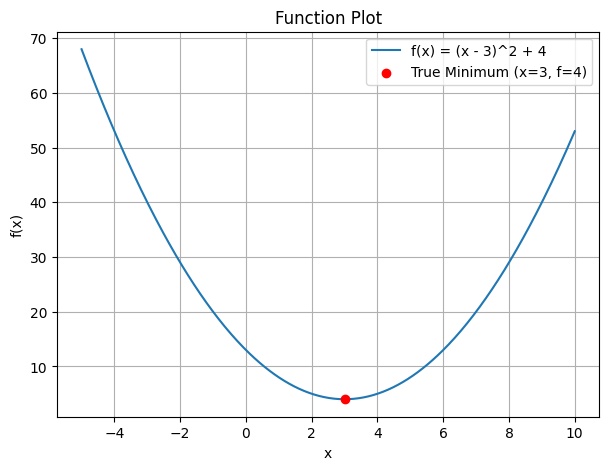

LR=0.01: iterations=200, diverged=True
LR=0.1: iterations=65, diverged=False
LR=0.9: iterations=75, diverged=False


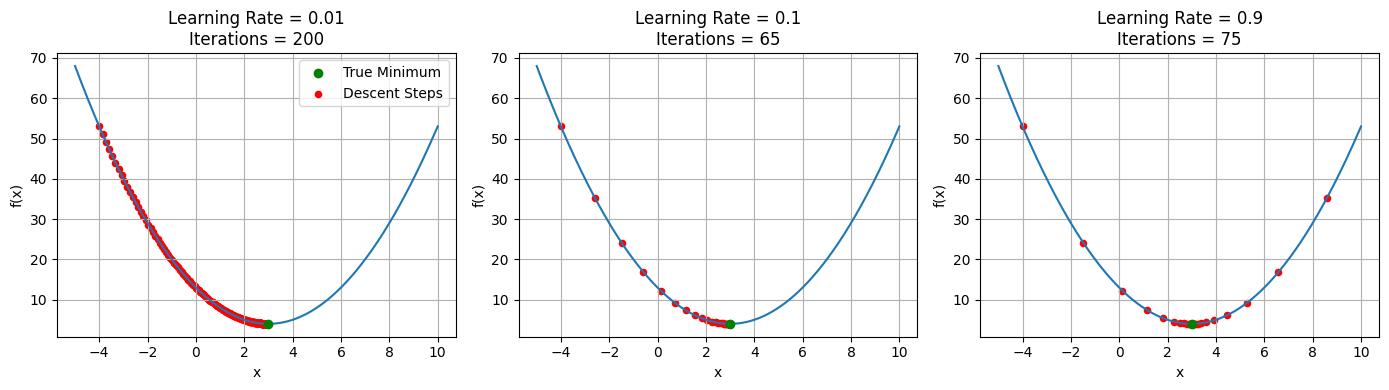

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Function Definition
# ============================

def f(x):
    return (x - 3)**2 + 4

def df(x):
    return 2*(x - 3)     # derivative

# ============================
# Plot the function
# ============================

x = np.linspace(-5, 10, 400)
y = f(x)

plt.figure(figsize=(7,5))
plt.plot(x, y, label="f(x) = (x - 3)^2 + 4")
plt.scatter(3, 4, color="red", label="True Minimum (x=3, f=4)", zorder=5)
plt.title("Function Plot")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# ============================
# Gradient Descent Function
# ============================

def gradient_descent(x0, lr, max_iters=200, tol=1e-6):
    x_vals = [x0]
    x = x0

    for i in range(max_iters):
        grad = df(x)
        new_x = x - lr * grad

        x_vals.append(new_x)

        if abs(new_x - x) < tol:
            return np.array(x_vals), i+1, False  # converged

        x = new_x

    return np.array(x_vals), max_iters, True  # hit max iterations (likely diverging)

# ============================
# Run GD for three learning rates
# ============================

learning_rates = [0.01, 0.1, 0.9]
results = {}

for lr in learning_rates:
    steps, iters, diverged = gradient_descent(-4, lr)
    results[lr] = (steps, iters, diverged)
    print(f"LR={lr}: iterations={iters}, diverged={diverged}")

# ============================
# Visualization of descent steps
# ============================

plt.figure(figsize=(14,4))

for idx, lr in enumerate(learning_rates):
    steps, iters, diverged = results[lr]
    plt.subplot(1, 3, idx+1)

    plt.plot(x, y)
    plt.scatter(3, 4, color="green", label="True Minimum", zorder=5)
    plt.scatter(steps, f(steps), color="red", s=20, label="Descent Steps")

    plt.title(f"Learning Rate = {lr}\nIterations = {iters}")
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True)

    if idx == 0:
        plt.legend()

plt.tight_layout()
plt.show()

# Expected Behavior
LR = 0.01

	•	Learning rate too small:
	•	Steps are tiny.

	•	Very small steps
	•	Slow convergence
	•	Smooth and stable
	•	Many iterations needed

LR = 0.1

	•	Fastest and smoothest convergence
	•	Reaches minimum quickly without oscillation

LR = 0.9

	•	Overshoots repeatedly
	•	Oscillates wildly or diverges
	•	Rarely converges within iteration limit


#Part C — Reflection


##1. Which learning rate gave the smoothest convergence?

The learning rate 0.1 produced the smoothest and fastest convergence.

It balanced speed and stability.

⸻

##2. What happens when the learning rate is too large?

When the learning rate is too large:

	•	Gradient steps become huge
	•	The algorithm jumps over the minimum
	•	It oscillates or completely diverges
	•	The cost increases instead of decreasing

This behavior matches LR = 0.9 in the experiment.

⸻

##3. How would you tune the learning rate in a real ML model?

Use an empirical tuning strategy:

	1.	Start with a moderate value (e.g., 0.01).
	2.	Train the model while monitoring loss.
	3.	If training is slow → increase LR.
	4.	If loss oscillates or diverges → decrease LR.
	5.	Optionally use:
  
	•	Learning rate schedules (decay over time)
	•	Adaptive optimizers like Adam, RMSProp
	•	Learning rate finder (increase LR until loss explodes)
